<a href="https://colab.research.google.com/github/2303A54051/HPC-PROJECT/blob/main/HPC_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Serial Fibonacci**

In [ ]:
%%writefile serial_fibonacci.c
#include <stdio.h>
#include <time.h>

// Serial recursive Fibonacci
long long fib(int n) {
    if (n <= 1) return n;
    return fib(n-1) + fib(n-2);
}

int main() {
    int n;
    printf("Enter value of n: ");
    scanf("%d", &n);

    clock_t start = clock();
    long long result = fib(n);
    clock_t end = clock();

    printf("Serial Fibonacci(%d) = %lld\n", n, result);
    printf("Execution Time = %f seconds\n", (double)(end - start)/CLOCKS_PER_SEC);
    return 0;
}

Overwriting serial_fibonacci.c


**Parallel Fibonacci**


In [ ]:
%%writefile parallel_fibonacci.c
#include <stdio.h>
#include <omp.h>

// Parallel recursive Fibonacci
long long fib(int n) {
    if (n <= 1) return n;

    long long x, y;

    #pragma omp task shared(x)
    x = fib(n - 1);

    #pragma omp task shared(y)
    y = fib(n - 2);
    #pragma omp taskwait
    return x + y;
}

int main() {
    int n;
    long long result;

    printf("Enter value of n: ");
    scanf("%d", &n);

    double start = omp_get_wtime();

    #pragma omp parallel
    {
        #pragma omp single
        result = fib(n);
    }

    double end = omp_get_wtime();

    printf("Parallel Fibonacci(%d) = %lld\n", n, result);
    printf("Execution Time = %f seconds\n", end - start);

    return 0;
}

Overwriting parallel_fibonacci.c


**Compile Both Programs**

In [ ]:
!gcc serial_fibonacci.c -o serial_fibonacci
!gcc -fopenmp parallel_fibonacci.c -o parallel_fibonacci


**Serial Execution**

In [ ]:
!echo 35 | ./serial_fibonacci

Enter value of n: Serial Fibonacci(35) = 9227465
Execution Time = 0.102839 seconds


**Parallel Execution (OpenMP):**

In [ ]:
!echo 35 | ./parallel_fibonacci

Enter value of n: Parallel Fibonacci(35) = 9227465
Execution Time = 8.033621 seconds


**Performance Graph**

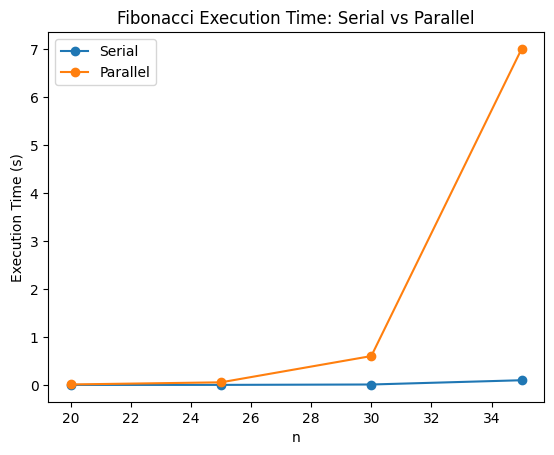

In [ ]:
import matplotlib.pyplot as plt
import subprocess

n_values = [20, 25, 30, 35]
serial_times = []
parallel_times = []

for n in n_values:
    # Serial
    serial_out = subprocess.getoutput(f'echo {n} | ./serial_fibonacci')
    serial_time = float(serial_out.split("Execution Time = ")[1].split(" ")[0])
    serial_times.append(serial_time)

    # Parallel
    parallel_out = subprocess.getoutput(f'echo {n} | ./parallel_fibonacci')
    parallel_time = float(parallel_out.split("Execution Time = ")[1].split(" ")[0])
    parallel_times.append(parallel_time)

plt.plot(n_values, serial_times, marker='o', label='Serial')
plt.plot(n_values, parallel_times, marker='o', label='Parallel')
plt.xlabel("n")
plt.ylabel("Execution Time (s)")
plt.title("Fibonacci Execution Time: Serial vs Parallel")
plt.legend()
plt.show()